# **MÓDULO 18 - Pratique**
# Regressão Linear

Agora que aprendemos como aplicar a regressão linear simples e múltipla, colocaremos em prática os conceitos vistos na aula.

Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo.

**Atenção! Esse é seu primeiro modelo, caso tenha dificuldade conte com a ajuda da tutoria**

Você notará que alguns códigos já estão presentes para facilitar a construção de vocês.

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [99]:
df = pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')

df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

Os dados já estão em formato inteiro e não possuem valores nulos, então não é necessário fazer substituição nem remover dados.

In [100]:
#Seu código aqui
df.dtypes

Valor_Aluguel       int64
Valor_Condominio    int64
Metragem            int64
N_Quartos           int64
N_banheiros         int64
N_Suites            int64
N_Vagas             int64
dtype: object

In [101]:
df.isnull().sum()

Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64

# 2 - Realize a segunda etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

In [102]:
#Seu código aqui
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


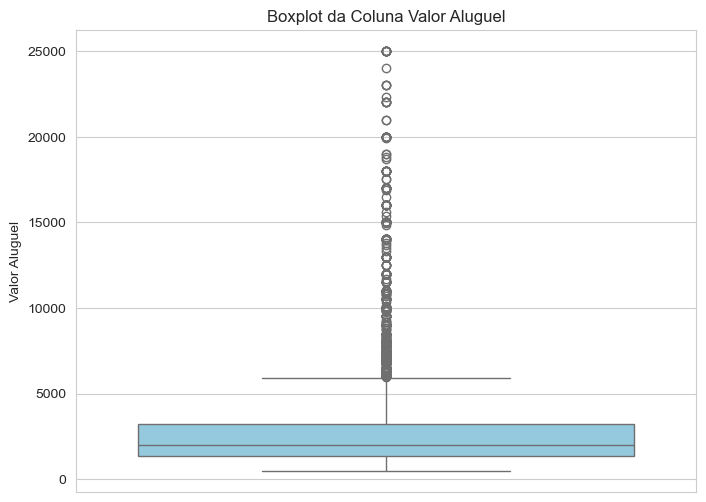

In [103]:
sns.set_style('whitegrid')

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='Valor_Aluguel', color='skyblue')
plt.title('Boxplot da Coluna Valor Aluguel')
plt.ylabel('Valor Aluguel')
plt.show()

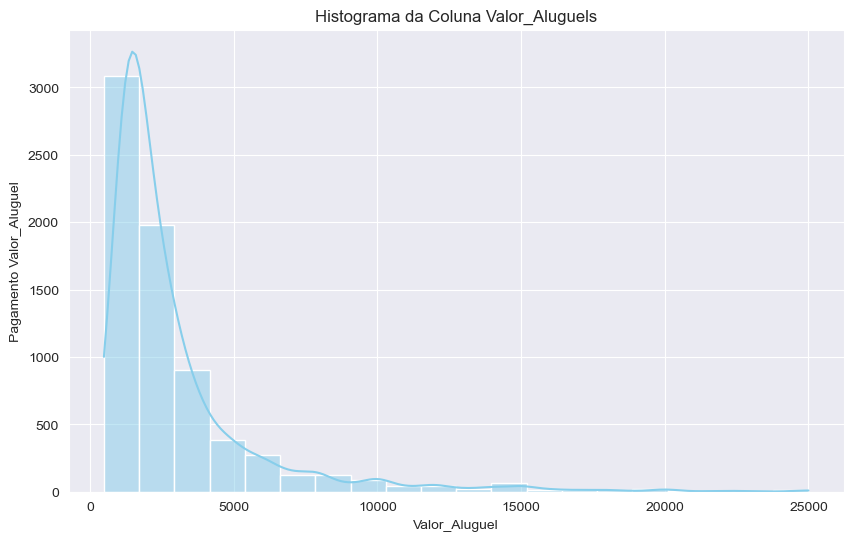

In [104]:
sns.set_style('darkgrid')
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Valor_Aluguel', bins=20, kde=True, color='skyblue')
plt.title('Histograma da Coluna Valor_Aluguels')
plt.ylabel('Pagamento Valor_Aluguel')
plt.show()

In [105]:
print ("Porcentagem de registros onde 'Valor_Aluguel' > 15000: ",
       (len(df[df['Valor_Aluguel'] > 15000])/len(df))*100)

Porcentagem de registros onde 'Valor_Aluguel' > 15000:  1.0828821324448146


Resposta:
C) Observa-se uma relação positiva entre o número de vagas e o valor do aluguel, indicando que imóveis com mais vagas tendem a apresentar preços mais elevados. Além disso, há maior dispersão nos valores conforme aumenta o número de vagas, sugerindo maior diversidade de padrões dentro desses grupos. Também foram identificados outliers em todas as categorias, o que pode estar relacionado a imóveis de alto padrão ou localizações privilegiadas. Nota-se que quanto maior a metragem do imóvel, maior tende a ser o valor do aluguel, evidenciando uma relação direta entre espaço disponível e preço. Da mesma forma, imóveis com maior número de quartos também apresentam valores mais elevados, reforçando que características estruturais influenciam significativamente no valor final do aluguel.

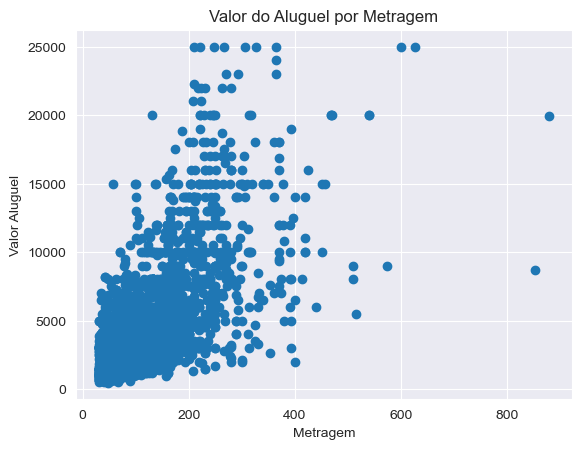

In [106]:
plt.scatter(df['Metragem'], df['Valor_Aluguel'])
plt.xlabel('Metragem')
plt.ylabel('Valor Aluguel')
plt.title('Valor do Aluguel por Metragem')
plt.show()

Text(0.5, 1.0, 'Valor do Aluguel por Número de Vagas')

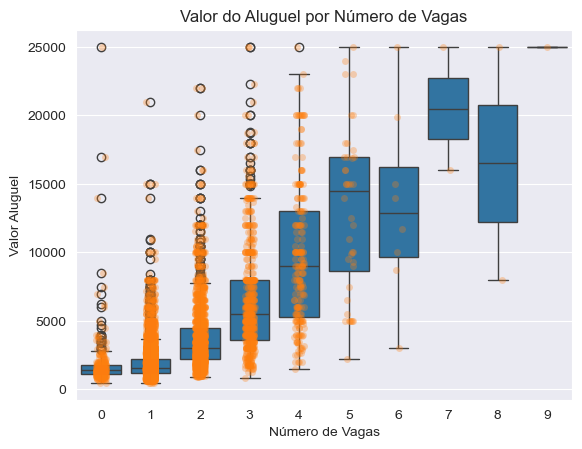

In [107]:
sns.boxplot(x='N_Vagas', y='Valor_Aluguel', data=df)
sns.stripplot(x='N_Vagas', y='Valor_Aluguel', data=df, alpha=0.3)
plt.xlabel('Número de Vagas')
plt.ylabel('Valor Aluguel')
plt.title('Valor do Aluguel por Número de Vagas')

Text(0.5, 1.0, 'Valor do Aluguel por Número de Quartos')

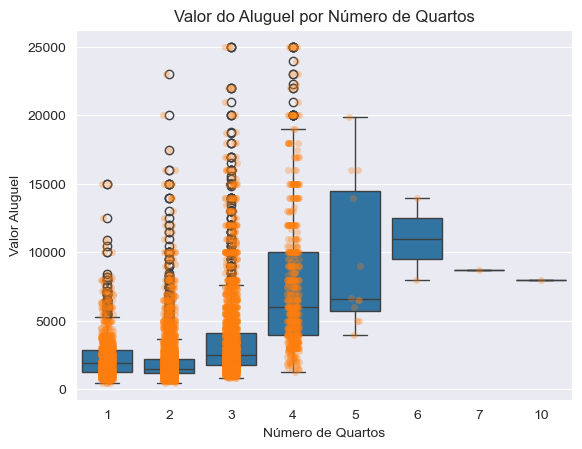

In [108]:
sns.boxplot(x='N_Quartos', y='Valor_Aluguel', data=df)
sns.stripplot(x='N_Quartos', y='Valor_Aluguel', data=df, alpha=0.3)
plt.xlabel('Número de Quartos')
plt.ylabel('Valor Aluguel')
plt.title('Valor do Aluguel por Número de Quartos')



# 3 - Realize a terceira etapa de pré processamento dos dados.

A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.




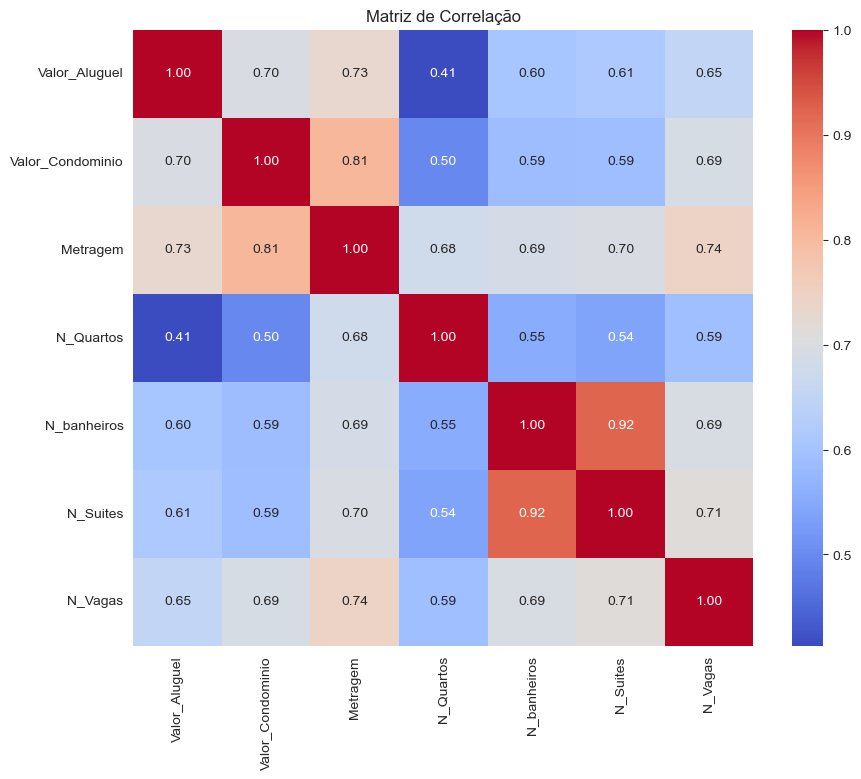

In [109]:
#Seu código aqui
correlation_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()


B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [110]:
X = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

Dica: Para separar em treino e teste usamos o train_test_split, como visto nas aulas de pré modelagem.

In [111]:
# Seu código aqui
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 3 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [112]:
X = X_train[['Metragem']]  # Variável independente (características)
y = y_train  # Variável dependente (rótulo)
# se você deu um nome diferente para x train e y train, altere no código.

In [113]:
#Crie seu modelo aqui, usando LinearRegression e as bases de treino.
df['Metragem'].corr(df['Valor_Aluguel'])

np.float64(0.7305905908975058)

In [114]:
regressao_valor_aluguel = LinearRegression()

regressao_valor_aluguel.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

In [115]:
#Seu código Aqui
regressao_valor_aluguel.intercept_

np.float64(-103.17820863080169)

In [116]:
regressao_valor_aluguel.coef_

array([34.70818769])

Nossa equação seria:  VALOR_ALUGUEL = -103,18*(METRAGEM) + 34,71

c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

In [117]:
#Seu código aqui

regressao_valor_aluguel.score(X,y)

0.5213271756253639

O modelo apresentou um coeficiente de determinação (R²) de 0,52, indicando que aproximadamente 52% da variação do valor do aluguel é explicada pelas variáveis utilizadas. Esse resultado sugere um poder explicativo moderado, indicando que outras variáveis não incluídas no modelo também influenciam significativamente o preço dos imóveis.

D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

O gráfico de regressão indica uma relação positiva entre a metragem e o valor do aluguel, evidenciando que imóveis maiores tendem a apresentar preços mais elevados. No entanto, observa-se uma dispersão considerável dos dados em torno da linha de regressão, indicando que a metragem, isoladamente, não é suficiente para explicar totalmente a variação dos preços. A presença de outliers sugere a existência de imóveis de alto padrão ou fatores adicionais, como localização e características do imóvel, que influenciam no valor do aluguel.

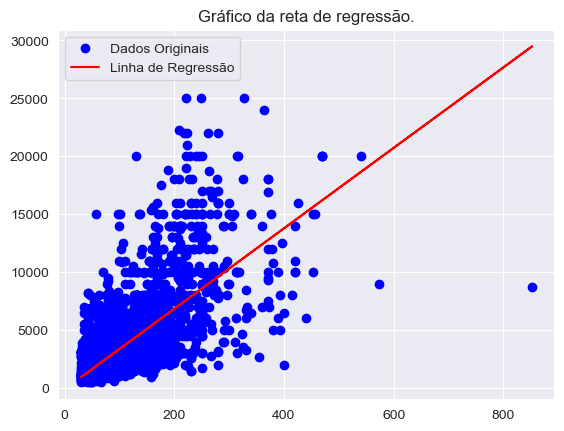

In [118]:
# Seu código aqui
plt.scatter(X, y, color='blue', label='Dados Originais')

# Plotar a linha de regressão
plt.plot(X, regressao_valor_aluguel.predict(X), color='red', label='Linha de Regressão')
plt.legend()
plt.title('Gráfico da reta de regressão.') 
plt.show()

E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
Para isso altere no código abaixo o nome do seu modelo de regressão:

In [119]:
X_test = X_test[['Metragem']]  # Variável independente (características)
y_test = y_test  # Variável dependente (rótulo)

In [120]:
# Usando o modelo treinado para fazer previsões sobre os dados de teste
previsoes = regressao_valor_aluguel.predict(X_test)

# Avaliando o desempenho do modelo usando métricas como o R²
r2 = regressao_valor_aluguel.score(X_test, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)


Coeficiente de Determinação (R²) nos Dados de Teste: 0.5651600449476675


Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

F) Avalie com suas palavras o valor do r quadrado encontrado no treino e no teste.

Escreva sua resposta aqui.
O modelo apresentou R² de 0,52 nos dados de treinamento e 0,56 nos dados de teste. A proximidade entre esses valores indica que o modelo possui boa capacidade de generalização, não apresentando sinais de overfitting. O desempenho ligeiramente superior no conjunto de teste pode estar associado à variabilidade dos dados.

# 4 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

In [121]:
#seu código aqui
A = df.drop('Valor_Aluguel', axis=1)
b = df['Valor_Aluguel'] 

In [122]:
A_train, A_test, b_train, b_test = train_test_split(A, b, test_size=0.25, random_state=42)

B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [124]:
#seu código aqui
regressao_multipla = LinearRegression()
regressao_multipla.fit(A_train, b_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [126]:
print("Intercepto:", regressao_multipla.intercept_)
print("Coeficientes:", regressao_multipla.coef_)

Intercepto: 411.92895077384674
Coeficientes: [   0.77302112   20.72122898 -659.00604215  240.76046013  340.61447028
  522.98401929]


C) Traga o valor do R quadrado e avalie o valor encontrado.

O modelo de regressão linear múltipla do treinamento apresentou um R² de 0,61, indicando que aproximadamente 61% da variação do valor do aluguel é explicada pelas variáveis utilizadas. 

In [130]:
#seu código aqui
regressao_multipla.score(A,b)

0.6072329037304596

D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.

O modelo de regressão linear múltipla do teste apresentou um R² de 0,60, indicando que aproximadamente 60% da variação do valor do aluguel é explicada pelas variáveis utilizadas. 

In [128]:
#seu código aqui
regressao_multipla_teste = LinearRegression()
regressao_multipla_teste.fit(A_test, b_test)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [129]:
regressao_multipla_teste.score(A,b)

0.6049488995163277

E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

Digite sua resposta aqui
Observou-se que o modelo de regressão múltipla apresentou um resultado melhor que o modelo simples, mostrando que usar mais variáveis melhora o desempenho. Mesmo assim, ainda existem fatores que não foram considerados, como a localização e características específicas dos imóveis, que também influenciam no valor do aluguel.